# Part 3 — PyTorch FFNN with Entity Embeddings

**Dataset:** BTS multi-year flights (Jan 2023 – Dec 2025, ~19.5M labelled rows)  
**Train:** 1.5M sampled rows from 2023-2024 (temporal split)  
**Test:** 500K sampled rows from 2025  
**Architecture:** Entity embeddings for airport/carrier + FC layers (mirrors Part 2 `06_neural_network.ipynb`)

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
config.assert_data_exists()

Device: cuda


## 1. Load Processed Features

In [2]:
feat_path = config.DATA_PART3_PROCESSED / "flights_2023_2025_features.parquet"
df = pd.read_parquet(feat_path)
print(f"Total rows: {len(df):,}  |  Columns: {df.columns.tolist()}")
print(f"YEAR distribution:\n{df['YEAR'].value_counts().sort_index()}")

Total rows: 20,588,154  |  Columns: ['MONTH', 'month_sin', 'month_cos', 'DAY_OF_WEEK', 'dow_sin', 'dow_cos', 'dep_hour', 'dep_minutes_since_midnight', 'is_peak_hour', 'is_red_eye', 'CRS_ELAPSED_TIME', 'DISTANCE', 'route_delay_rate', 'carrier_delay_rate', 'ORIGIN', 'DEST', 'OP_CARRIER', 'ARR_DEL15', 'YEAR']
YEAR distribution:
YEAR
2023    6743403
2024    6965267
2025    6879484
Name: count, dtype: int64


## 2. Train / Test Split & Sampling

In [3]:
TARGET = "ARR_DEL15"
CAT_COLS = ["ORIGIN", "DEST", "OP_CARRIER"]
NUM_COLS = [
    "MONTH", "month_sin", "month_cos",
    "DAY_OF_WEEK", "dow_sin", "dow_cos",
    "dep_hour", "dep_minutes_since_midnight",
    "is_peak_hour", "is_red_eye",
    "CRS_ELAPSED_TIME", "DISTANCE",
    "route_delay_rate", "carrier_delay_rate",
]

TRAIN_SAMPLE = 1_500_000
TEST_SAMPLE  =   500_000

train_pool = df[df["YEAR"] <= 2024]
test_pool  = df[df["YEAR"] == 2025]

train_df = train_pool.sample(n=TRAIN_SAMPLE, random_state=42)
test_df  = test_pool.sample(n=min(TEST_SAMPLE, len(test_pool)), random_state=42)

print(f"Train sample: {len(train_df):,}  delay rate: {train_df[TARGET].mean():.3f}")
print(f"Test sample:  {len(test_df):,}  delay rate: {test_df[TARGET].mean():.3f}")

Train sample: 1,500,000  delay rate: 0.206
Test sample:  500,000  delay rate: 0.223


## 3. Encode Categorical Features

In [4]:
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    train_df = train_df.copy()
    test_df  = test_df.copy()
    le.fit(train_df[col].astype(str))
    train_df[col] = le.transform(train_df[col].astype(str))
    # Handle unseen labels in test (map to 0)
    test_df[col] = test_df[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else 0
    )
    encoders[col] = le

vocab_sizes = {col: len(enc.classes_) for col, enc in encoders.items()}
# FastAI rule: embed_dim = min(50, (vocab + 1) // 2)
embed_dims  = {col: min(50, (v + 1) // 2) for col, v in vocab_sizes.items()}
print("Vocab sizes:", vocab_sizes)
print("Embed dims: ", embed_dims)

Vocab sizes: {'ORIGIN': 354, 'DEST': 354, 'OP_CARRIER': 15}
Embed dims:  {'ORIGIN': 50, 'DEST': 50, 'OP_CARRIER': 8}


## 4. Dataset

In [5]:
class FlightDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cats   = torch.tensor(df[cat_cols].values, dtype=torch.long)
        nums_arr    = df[num_cols].fillna(0).values.astype(np.float32)
        self.nums   = torch.tensor(nums_arr, dtype=torch.float32)
        self.labels = torch.tensor(df[target].values.astype(np.float32), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.cats[idx], self.nums[idx], self.labels[idx]

In [6]:
# 80/20 validation split from training sample
val_size = int(0.2 * len(train_df))
val_df   = train_df.iloc[:val_size]
fit_df   = train_df.iloc[val_size:]

BATCH = 4096
train_ds = FlightDataset(fit_df, CAT_COLS, NUM_COLS, TARGET)
val_ds   = FlightDataset(val_df,  CAT_COLS, NUM_COLS, TARGET)
test_ds  = FlightDataset(test_df, CAT_COLS, NUM_COLS, TARGET)

# num_workers=0: tensors are pre-built in __init__, forked workers don't help in subprocess
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=device.type=="cuda")
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=device.type=="cuda")
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=device.type=="cuda")

print(f"Fit: {len(fit_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Fit: 1,200,000 | Val: 300,000 | Test: 500,000


## 5. Model

In [7]:
class FlightFFNN(nn.Module):
    def __init__(self, vocab_sizes, embed_dims, n_numeric):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], embed_dims[col])
            for col in CAT_COLS
        ])
        total_embed = sum(embed_dims[col] for col in CAT_COLS)
        input_dim = total_embed + n_numeric

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def forward(self, cats, nums):
        embs = [emb(cats[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [nums], dim=1)
        return self.net(x).squeeze(1)


model = FlightFFNN(vocab_sizes, embed_dims, n_numeric=len(NUM_COLS)).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)

Trainable parameters: 109,121
FlightFFNN(
  (embeddings): ModuleList(
    (0-1): 2 x Embedding(354, 50)
    (2): Embedding(15, 8)
  )
  (net): Sequential(
    (0): Linear(in_features=122, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 6. Training

In [8]:
EPOCHS = 20

# Class imbalance weight
n_neg = (fit_df[TARGET] == 0).sum()
n_pos = (fit_df[TARGET] == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"pos_weight: {pos_weight.item():.3f}  (neg={n_neg:,}, pos={n_pos:,})")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3,
    anneal_strategy="cos",
)

pos_weight: 3.850  (neg=952,573, pos=247,427)


In [9]:
def run_epoch(loader, train=True):
    model.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for cats, nums, labels in loader:
            cats, nums, labels = cats.to(device), nums.to(device), labels.to(device)
            logits = model(cats, nums)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc


best_val_auc = 0.0
best_epoch   = 0
model_path   = config.DATA_PART3_PROCESSED / "ffnn_best.pt"
history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc = run_epoch(train_loader, train=True)
    vl_loss, vl_auc = run_epoch(val_loader,   train=False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_auc"].append(tr_auc)
    history["val_auc"].append(vl_auc)
    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        best_epoch   = epoch
        torch.save(model.state_dict(), model_path)
    print(f"Epoch {epoch:02d}/{EPOCHS}  train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
          f"train_auc={tr_auc:.4f}  val_auc={vl_auc:.4f}"
          + (" ← best" if epoch == best_epoch else ""))

print(f"\nBest val AUC: {best_val_auc:.4f} at epoch {best_epoch}")

Epoch 01/20  train_loss=1.0819  val_loss=1.0658  train_auc=0.6010  val_auc=0.6199 ← best


Epoch 02/20  train_loss=1.0689  val_loss=1.0628  train_auc=0.6153  val_auc=0.6244 ← best


Epoch 03/20  train_loss=1.0563  val_loss=1.0472  train_auc=0.6351  val_auc=0.6508 ← best


Epoch 04/20  train_loss=1.0440  val_loss=1.0500  train_auc=0.6517  val_auc=0.6563 ← best


Epoch 05/20  train_loss=1.0387  val_loss=1.0535  train_auc=0.6580  val_auc=0.6582 ← best


...

Epoch 16/20  train_loss=1.0216  val_loss=1.0234  train_auc=0.6775  val_auc=0.6762 ← best


Epoch 17/20  train_loss=1.0204  val_loss=1.0227  train_auc=0.6787  val_auc=0.6767 ← best


Epoch 18/20  train_loss=1.0199  val_loss=1.0220  train_auc=0.6792  val_auc=0.6772 ← best


Epoch 19/20  train_loss=1.0196  val_loss=1.0218  train_auc=0.6794  val_auc=0.6775 ← best


Epoch 20/20  train_loss=1.0193  val_loss=1.0218  train_auc=0.6799  val_auc=0.6775 ← best

Best val AUC: 0.6775 at epoch 20


## 7. Learning Curves

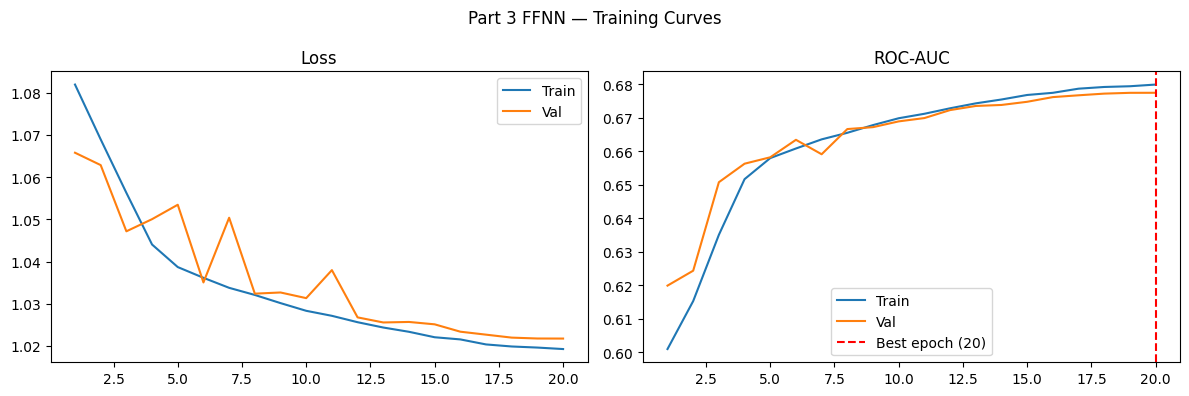

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history["train_loss"], label="Train")
axes[0].plot(epochs_x, history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_x, history["train_auc"], label="Train")
axes[1].plot(epochs_x, history["val_auc"],   label="Val")
axes[1].axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch ({best_epoch})")
axes[1].set_title("ROC-AUC")
axes[1].legend()

plt.suptitle("Part 3 FFNN — Training Curves")
plt.tight_layout()
plt.show()

## 8. Evaluate on 2025 Test Set

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for cats, nums, labels in test_loader:
        cats, nums = cats.to(device), nums.to(device)
        logits = model(cats, nums)
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs >= 0.5).astype(int)

acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
f1  = f1_score(all_labels, all_preds)

print("=== Part 3 FFNN — 2025 Test Set ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}")
print(f"F1:       {f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=["On-Time", "Delayed"]))

=== Part 3 FFNN — 2025 Test Set ===
Accuracy: 0.6264
ROC-AUC:  0.6533
F1:       0.4089

              precision    recall  f1-score   support

     On-Time       0.84      0.64      0.73    388314
     Delayed       0.32      0.58      0.41    111686

    accuracy                           0.63    500000
   macro avg       0.58      0.61      0.57    500000
weighted avg       0.72      0.63      0.66    500000



## 9. Final Comparison Table

In [12]:
results = [
    # Part 3 models (temporal split: 2023-24 train / 2025 test)
    {"Model": "LightGBM Baseline (Part 3)",  "Accuracy": 0.7773, "ROC-AUC": 0.6592, "F1": 0.0950},
    {"Model": "LightGBM Tuned (Part 3)",     "Accuracy": 0.7772, "ROC-AUC": 0.6602, "F1": 0.0977},
    {"Model": "XGBoost Baseline (Part 3)",   "Accuracy": 0.7775, "ROC-AUC": 0.6486, "F1": 0.0655},
    {"Model": "PyTorch FFNN (Part 3)",       "Accuracy": round(acc, 4), "ROC-AUC": round(auc, 4), "F1": round(f1, 4)},
    # Part 2 reference (random within-year split)
    {"Model": "XGBoost Tuned (Part 2 ref)",  "Accuracy": 0.7990, "ROC-AUC": 0.8480, "F1": None},
    {"Model": "PyTorch FFNN (Part 2 ref)",   "Accuracy": 0.7980, "ROC-AUC": 0.8513, "F1": None},
]

summary = pd.DataFrame(results).set_index("Model")
print(summary.to_string())

                            Accuracy  ROC-AUC      F1
Model                                                
LightGBM Baseline (Part 3)    0.7773   0.6592  0.0950
LightGBM Tuned (Part 3)       0.7772   0.6602  0.0977
XGBoost Baseline (Part 3)     0.7775   0.6486  0.0655
PyTorch FFNN (Part 3)         0.6264   0.6533  0.4089
XGBoost Tuned (Part 2 ref)    0.7990   0.8480     NaN
PyTorch FFNN (Part 2 ref)     0.7980   0.8513     NaN
